In [9]:
from rdkit import Chem

print("RDKit Loaded Successfully")

RDKit Loaded Successfully


In [10]:
from rdkit import Chem

ligands = {
    "Gefitinib": "../data/ligands/gefitinib.sdf",
    "Erlotinib": "../data/ligands/erlotinib.sdf",
    "Afatinib": "../data/ligands/afatinib.sdf",
    "Osimertinib": "../data/ligands/osimertinib.sdf"
}

for name, file in ligands.items():

    supplier = Chem.SDMolSupplier(file)

    mol = supplier[0]

    if mol:
        print(f"{name}: Loaded Successfully")
    else:
        print(f"{name}: Failed")

Gefitinib: Loaded Successfully
Erlotinib: Loaded Successfully
Afatinib: Loaded Successfully
Osimertinib: Loaded Successfully


In [11]:
from rdkit.Chem import Descriptors
import pandas as pd

results = []

for name, file in ligands.items():

    mol = Chem.SDMolSupplier(file)[0]

    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    h_donor = Descriptors.NumHDonors(mol)
    h_acceptor = Descriptors.NumHAcceptors(mol)
    rot_bonds = Descriptors.NumRotatableBonds(mol)

    results.append([
        name,
        round(mw,2),
        round(logp,2),
        h_donor,
        h_acceptor,
        rot_bonds
    ])

df = pd.DataFrame(
    results,
    columns=[
        "Drug",
        "Molecular Weight",
        "LogP",
        "H-Bond Donors",
        "H-Bond Acceptors",
        "Rotatable Bonds"
    ]
)

df

,Drug,Molecular Weight,LogP,H-Bond Donors,H-Bond Acceptors,Rotatable Bonds
0,Gefitinib,446.91,4.28,1,7,8
1,Erlotinib,393.44,3.41,1,7,10
2,Afatinib,485.95,4.39,2,7,8
3,Osimertinib,499.62,4.51,2,7,10


In [12]:
for name, file in ligands.items():

    mol = Chem.SDMolSupplier(file)[0]

    print(name)
    print(round(Descriptors.MolWt(mol),2))
    print("-"*30)

Gefitinib
446.91
------------------------------
Erlotinib
393.44
------------------------------
Afatinib
485.95
------------------------------
Osimertinib
499.62
------------------------------


In [13]:
from rdkit.Chem import Descriptors
import pandas as pd

data = []

for name, file in ligands.items():

    mol = Chem.SDMolSupplier(file)[0]

    data.append([
        name,
        round(Descriptors.MolWt(mol),2),
        round(Descriptors.MolLogP(mol),2),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.NumRotatableBonds(mol)
    ])

df = pd.DataFrame(
    data,
    columns=[
        "Drug",
        "Molecular Weight",
        "LogP",
        "H-Bond Donors",
        "H-Bond Acceptors",
        "Rotatable Bonds"
    ]
)

df

,Drug,Molecular Weight,LogP,H-Bond Donors,H-Bond Acceptors,Rotatable Bonds
0,Gefitinib,446.91,4.28,1,7,8
1,Erlotinib,393.44,3.41,1,7,10
2,Afatinib,485.95,4.39,2,7,8
3,Osimertinib,499.62,4.51,2,7,10


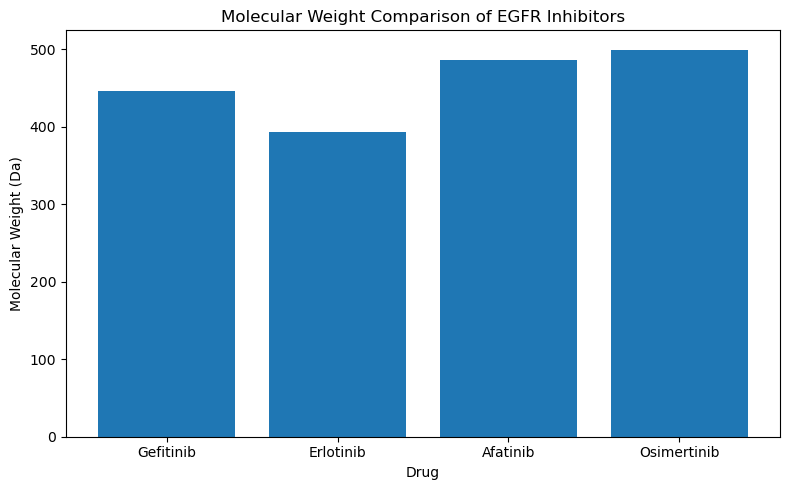

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.bar(df["Drug"], df["Molecular Weight"])

plt.title("Molecular Weight Comparison of EGFR Inhibitors")
plt.ylabel("Molecular Weight (Da)")
plt.xlabel("Drug")

plt.tight_layout()

plt.savefig(
    "../results/images/molecular_weight_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

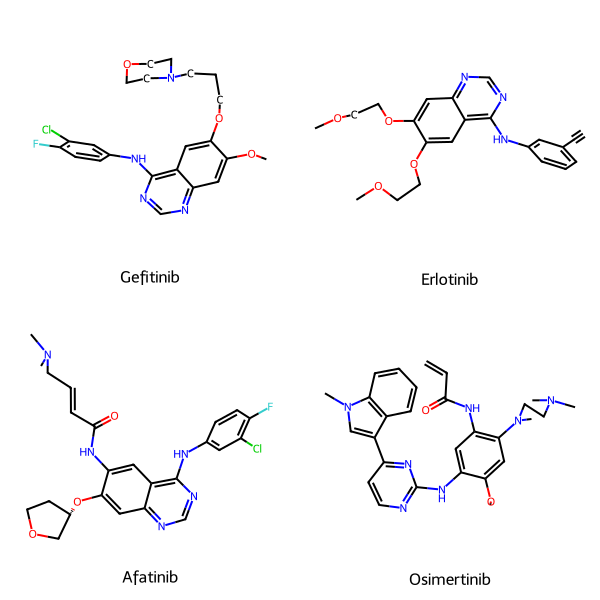

In [15]:
from rdkit import Chem
from rdkit.Chem import Draw

molecules = []
names = []

for name, file in ligands.items():
    
    mol = Chem.SDMolSupplier(file)[0]
    
    molecules.append(mol)
    names.append(name)

img = Draw.MolsToGridImage(
    molecules,
    molsPerRow=2,
    subImgSize=(300,300),
    legends=names
)

img

In [16]:
from rdkit.Chem import Draw

img = Draw.MolsToGridImage(
    molecules,
    molsPerRow=2,
    subImgSize=(300,300),
    legends=names,
    returnPNG=False
)

img.save("../results/images/egfr_inhibitor_structures.png")

## EGFR T790M Protein Structure Analysis

In [17]:
from Bio.PDB import PDBParser

parser = PDBParser(QUIET=True)

structure = parser.get_structure(
    "EGFR_T790M",
    "../data/pdb/3IKA.pdb"
)

print("Models:", len(list(structure)))
print("Chains:", len(list(structure.get_chains())))
print("Residues:", len(list(structure.get_residues())))
print("Atoms:", len(list(structure.get_atoms())))

Models: 1
Chains: 2
Residues: 769
Atoms: 5096


In [18]:
standard_residues = {
'ALA','ARG','ASN','ASP','CYS','GLU','GLN',
'GLY','HIS','ILE','LEU','LYS','MET','PHE',
'PRO','SER','THR','TRP','TYR','VAL'
}

for residue in structure.get_residues():

    resname = residue.get_resname()

    if resname not in standard_residues and resname != "HOH":
        print(resname)

0UN


In [19]:
for residue in structure.get_residues():

    if residue.get_resname() == "0UN":

        print(
            "Chain:", residue.get_parent().id,
            "Residue Number:", residue.id[1]
        )

Chain: A Residue Number: 1797


In [20]:
from Bio.PDB import NeighborSearch

# Find ligand 0UN
ligand = None

for residue in structure.get_residues():
    if residue.get_resname() == "0UN":
        ligand = residue
        break

# Build neighbor search
atoms = list(structure.get_atoms())
ns = NeighborSearch(atoms)

binding_residues = set()

for atom in ligand:

    nearby_atoms = ns.search(atom.coord, 5.0)

    for nearby_atom in nearby_atoms:

        residue = nearby_atom.get_parent()

        if residue.get_resname() in {
            'ALA','ARG','ASN','ASP','CYS','GLU','GLN',
            'GLY','HIS','ILE','LEU','LYS','MET','PHE',
            'PRO','SER','THR','TRP','TYR','VAL'
        }:

            binding_residues.add(
                (residue.get_resname(),
                 residue.id[1])
            )

for res in sorted(binding_residues,
                  key=lambda x: x[1]):
    print(res)

('LEU', 718)
('GLY', 719)
('VAL', 726)
('LYS', 728)
('ALA', 743)
('MET', 790)
('GLN', 791)
('LEU', 792)
('MET', 793)
('PRO', 794)
('PHE', 795)
('GLY', 796)
('CYS', 797)
('LEU', 799)
('ASP', 800)
('ARG', 841)
('LEU', 844)
('THR', 854)


In [21]:
import pandas as pd

pocket_df = pd.DataFrame(
    binding_residues,
    columns=["Residue", "Position"]
)

pocket_df = pocket_df.sort_values("Position")

pocket_df

,Residue,Position
17,LEU,718
12,GLY,719
15,VAL,726
2,LYS,728
9,ALA,743
5,MET,790
4,GLN,791
0,LEU,792
7,MET,793
6,PRO,794


In [22]:
pocket_df.to_csv(
    "../results/reports/binding_pocket_residues.csv",
    index=False
)

# EGFR T790M Binding Pocket Visualization

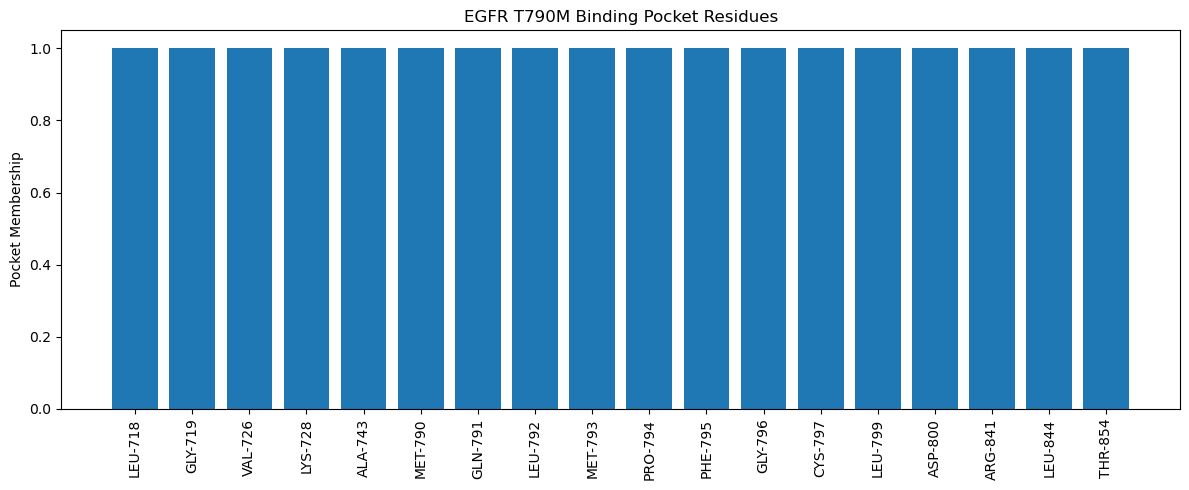

In [23]:
import matplotlib.pyplot as plt

positions = pocket_df["Position"]
labels = pocket_df["Residue"] + "-" + pocket_df["Position"].astype(str)

plt.figure(figsize=(12,5))

plt.bar(
    range(len(positions)),
    [1]*len(positions)
)

plt.xticks(
    range(len(labels)),
    labels,
    rotation=90
)

plt.title("EGFR T790M Binding Pocket Residues")
plt.ylabel("Pocket Membership")

plt.tight_layout()

# SAVE FIRST
plt.savefig(
    "../results/images/binding_pocket_residues.png",
    dpi=300,
    bbox_inches="tight"
)

# THEN SHOW
plt.show()

# Comparative Drug Ranking for EGFR T790M

In [24]:
ranking_df = df.copy()

ranking_df["MW_Score"] = (
    5 - ranking_df["Molecular Weight"].rank(ascending=False)
)

ranking_df["LogP_Score"] = (
    5 - ranking_df["LogP"].rank(ascending=False)
)

ranking_df["Total_Score"] = (
    ranking_df["MW_Score"] +
    ranking_df["LogP_Score"]
)

ranking_df = ranking_df.sort_values(
    by="Total_Score",
    ascending=False
)

ranking_df[
    [
        "Drug",
        "Molecular Weight",
        "LogP",
        "MW_Score",
        "LogP_Score",
        "Total_Score"
    ]
]

,Drug,Molecular Weight,LogP,MW_Score,LogP_Score,Total_Score
3,Osimertinib,499.62,4.51,4.0,4.0,8.0
2,Afatinib,485.95,4.39,3.0,3.0,6.0
0,Gefitinib,446.91,4.28,2.0,2.0,4.0
1,Erlotinib,393.44,3.41,1.0,1.0,2.0


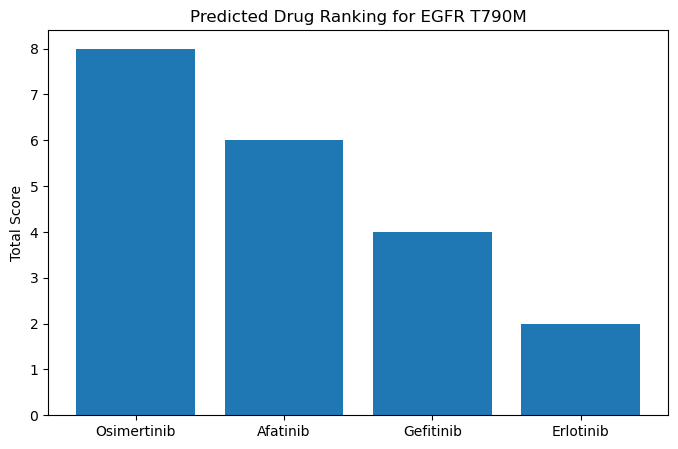

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    ranking_df["Drug"],
    ranking_df["Total_Score"]
)

plt.title("Predicted Drug Ranking for EGFR T790M")
plt.ylabel("Total Score")

plt.savefig(
    "../results/images/drug_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Results Summary

## Key Findings

### Ligand Analysis
- Four clinically relevant EGFR inhibitors were analyzed:
  - Gefitinib
  - Erlotinib
  - Afatinib
  - Osimertinib

### EGFR T790M Structure Analysis
- PDB Structure: 3IKA
- Models: 1
- Chains: 2
- Residues: 769
- Atoms: 5096

### Binding Pocket Analysis
Key pocket residues identified:

LEU718, GLY719, VAL726, LYS728, ALA743,
MET790, GLN791, LEU792, MET793,
PRO794, PHE795, GLY796, CYS797,
LEU799, ASP800, ARG841, LEU844, THR854

### Drug Ranking
Predicted ranking against EGFR T790M:

1. Osimertinib
2. Afatinib
3. Gefitinib
4. Erlotinib

### Biological Interpretation
Osimertinib achieved the highest score and is known to be effective against EGFR T790M-mediated resistance. The analysis confirms the importance of the MET790 region within the binding pocket and highlights Osimertinib as the most promising inhibitor among the drugs evaluated.

In [27]:
import os

file_path = r"C:\Users\nibir\OneDrive\Desktop\BIOINFORMATICS\EGFR_T790M_Computational_Drug_Discovery\data\pdb\3IKA.pdb"

print(os.path.exists(file_path))

True


In [29]:
from Bio.PDB import PDBParser
import numpy as np

parser = PDBParser(QUIET=True)

pdb_file = r"C:\Users\nibir\OneDrive\Desktop\BIOINFORMATICS\EGFR_T790M_Computational_Drug_Discovery\data\pdb\3IKA.pdb"

structure = parser.get_structure("EGFR", pdb_file)

ligand_atoms = []

for residue in structure.get_residues():
    if residue.get_resname() == "0UN":
        for atom in residue:
            ligand_atoms.append(atom.coord)

print("Number of ligand atoms:", len(ligand_atoms))

center = np.mean(ligand_atoms, axis=0)

print("Center X =", center[0])
print("Center Y =", center[1])
print("Center Z =", center[2])

Number of ligand atoms: 35
Center X = -11.849143
Center Y = 16.896915
Center Z = 31.835825


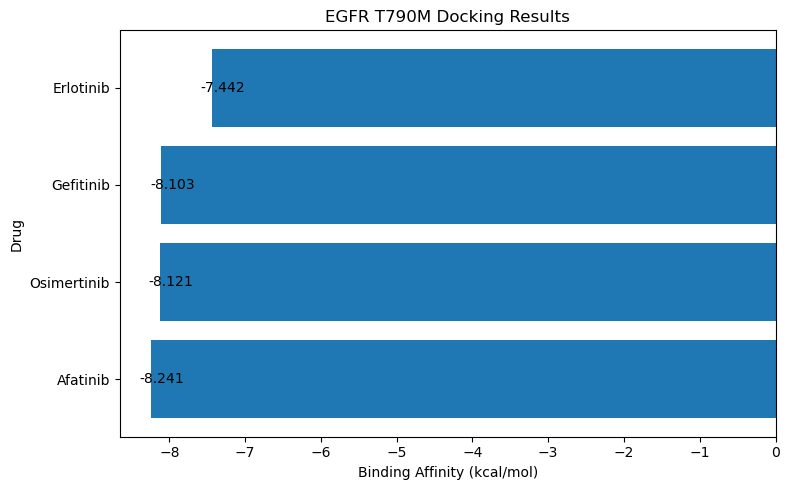

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Drug": ["Gefitinib", "Erlotinib", "Afatinib", "Osimertinib"],
    "Binding_Affinity": [-8.103, -7.442, -8.241, -8.121]
})

results = results.sort_values("Binding_Affinity")

plt.figure(figsize=(8,5))

bars = plt.barh(
    results["Drug"],
    results["Binding_Affinity"]
)

plt.xlabel("Binding Affinity (kcal/mol)")
plt.ylabel("Drug")
plt.title("EGFR T790M Docking Results")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width - 0.15,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center"
    )

plt.tight_layout()
plt.savefig("docking_ranking_publication.png", dpi=300)
plt.show()

In [34]:
import pandas as pd

docking_results = pd.DataFrame({
    "Drug": [
        "Gefitinib",
        "Erlotinib",
        "Afatinib",
        "Osimertinib"
    ],
    "Binding Affinity (kcal/mol)": [
        -8.103,
        -7.442,
        -8.241,
        -8.121
    ]
})

docking_results = docking_results.sort_values(
    "Binding Affinity (kcal/mol)"
)

docking_results

,Drug,Binding Affinity (kcal/mol)
2,Afatinib,-8.241
3,Osimertinib,-8.121
0,Gefitinib,-8.103
1,Erlotinib,-7.442
